# JuaKazi `sw-bias-classifier-v2` — Training Notebook

**Model card:** `juakazike/sw-bias-classifier-v2`  
**Base:** `Davlan/afro-xlmr-base` · **Task:** Swahili gender bias (binary)  
**Role:** Stage-2 ML fallback in JuaKazi pipeline (fires when rules engine finds nothing)  
**Runtime:** GPU T4 · ~45 min end-to-end  
**Target:** Val F1 ≥ 0.92

---

### Full Model Card

| Field | Value |
|---|---|
| Model ID | `juakazike/sw-bias-classifier-v2` |
| Base model | `Davlan/afro-xlmr-base` (560M params, 64-lang XLM-RoBERTa) |
| Task | Binary text classification — Swahili gender bias |
| Language | Swahili sw — Kenya + Tanzania dialects |
| Role | Stage 2 ML fallback (rules engine takes precedence) |
| License | MIT weights / CC-BY-4.0 training data |
| Version | v2 — supersedes v1 (miscalibrated head) |

**Intended use:** Detect implicit bias the rules engine misses — leadership/capability assumptions,
domestic role prescriptions, proverbs encoding gender hierarchy, unmarked male defaults.  
**Out-of-scope:** Non-Swahili text, real-time inference without human review flag.

**Training data:** `ground_truth_sw_v5.csv` (64,723 rows) — Zenodo 4300294, BBC Swahili,
AfriSenti, MasakhaNER, Wikipedia SW. Annotated via ann_sw_v3 AI pass + human batches 001–024.  
**Class imbalance:** ~1,300 bias : ~63,400 neutral (1:49). Fixed via 4:1 undersample + augmentation to 3,000 bias.

**Known limitations:** 98% news domain; no Sheng/Uganda; IAA (Cohen's κ) not yet measured.


In [1]:
# ── Cell 1: Install ─────────────────────────────────────────────────────────
# Fresh install — uninstall conflicting pre-installed packages first
import subprocess, sys

pkgs_to_remove = ["peft", "trl", "bitsandbytes"]
for p in pkgs_to_remove:
    subprocess.run([sys.executable, "-m", "pip", "uninstall", "-q", "-y", p], capture_output=True)

subprocess.run([
    sys.executable, "-m", "pip", "install", "-q",
    "transformers==4.38.2",
    "tokenizers==0.15.2",
    "accelerate==0.27.2",
    "scikit-learn==1.4.0",
    "huggingface_hub==0.20.3",
    "numpy==1.26.4",
], check=True)

print("Install done. Now do: Runtime → Restart session, then run from Cell 2.")


Install done. Now do: Runtime → Restart session, then run from Cell 2.


In [1]:
# ── Cell 2: Verify environment (run AFTER restart) ──────────────────────────
import torch, transformers, sklearn, numpy as np
print(f"torch:        {torch.__version__}")
print(f"transformers: {transformers.__version__}")
print(f"sklearn:      {sklearn.__version__}")
print(f"numpy:        {np.__version__}")
print(f"GPU:          {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'NONE — switch to T4!'}")
print(f"CUDA:         {torch.cuda.is_available()}")

# Verify Trainer imports cleanly
from transformers import Trainer, TrainingArguments, AutoTokenizer, AutoModelForSequenceClassification
from transformers import EarlyStoppingCallback
print("\nAll imports OK.")


torch:        2.10.0+cu128
transformers: 5.0.0
sklearn:      1.6.1
numpy:        2.0.2
GPU:          Tesla T4
CUDA:         True

All imports OK.


In [2]:
# ── Cell 3: Mount Drive + load ground truth ─────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os, csv

# Place ground_truth_sw_v5.csv in your Drive at: MyDrive/juakazi/ground_truth_sw_v5.csv
GT_CSV = '/content/drive/MyDrive/juakazi/ground_truth_sw_v5.csv'
assert os.path.exists(GT_CSV), f"Not found: {GT_CSV}\nUpload the file to Drive first."

with open(GT_CSV, encoding='utf-8') as f:
    rows = list(csv.DictReader(f))

bias_rows    = [r for r in rows if r.get('has_bias','').strip().lower() == 'true'  and r.get('text','').strip()]
neutral_rows = [r for r in rows if r.get('has_bias','').strip().lower() == 'false' and r.get('text','').strip()]

print(f"Total rows:  {len(rows):,}")
print(f"Biased:      {len(bias_rows):,}")
print(f"Neutral:     {len(neutral_rows):,}")
print(f"Raw ratio:   1:{len(neutral_rows)//max(len(bias_rows),1)}")

from collections import Counter
cats = Counter(r.get('stereotype_category','(none)') for r in bias_rows)
print("\nBias categories:")
for k, v in cats.most_common(10):
    print(f"  {v:5d}  {k}")


Mounted at /content/drive
Total rows:  64,723
Biased:      1,267
Neutral:     63,293
Raw ratio:   1:49

Bias categories:
   1004  profession
    115  capability
     52  family_role
     50  appearance
     26  personality
      9  leadership
      7  daily_life
      4  education


In [3]:
# ── Cell 4: Config + seeds ───────────────────────────────────────────────────
import random
import numpy as np
from pathlib import Path

SEED          = 42
BASE_MODEL    = 'Davlan/afro-xlmr-base'
OUTPUT_DIR    = '/content/output'
MAX_LEN       = 128
NEUTRAL_RATIO = 4       # 4 neutral rows per 1 bias row
BIAS_TARGET   = 3000    # augment bias class up to this count
TRAIN_SPLIT   = 0.85
EPOCHS        = 10
BATCH         = 16
LR            = 2e-5
WARMUP_RATIO  = 0.10
WEIGHT_DECAY  = 0.01
FREEZE_LAYERS = 6       # freeze bottom N encoder layers

random.seed(SEED)
np.random.seed(SEED)
import torch; torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
print("Config ready.")


Config ready.


In [4]:
# ── Cell 5: Augmentation ────────────────────────────────────────────────────
SW_SYNONYMS = {
    'mwanamke': 'msichana', 'msichana': 'mwanamke',
    'mwanaume': 'mvulana',  'mvulana':  'mwanaume',
    'kike':     'jinsia ya kike',
    'kiume':    'jinsia ya kiume',
    'mama':     'mzazi wa kike',
    'baba':     'mzazi wa kiume',
    'mke':      'mwenza',   'mume':     'mwenza',
    'daktari':  'mganga',   'mhandisi': 'fundi',
}

def augment(text: str) -> str:
    words = text.split()
    if random.random() < 0.5:
        for i, w in enumerate(words):
            lw = w.lower().rstrip('.,;')
            if lw in SW_SYNONYMS:
                words[i] = SW_SYNONYMS[lw]
                break
    if random.random() < 0.3 and len(words) > 5:
        words.pop(random.randint(1, len(words) - 2))
    return ' '.join(words)

# Smoke test
sample = bias_rows[0]['text']
print("Original: ", sample[:80])
print("Augmented:", augment(sample)[:80])


Original:  Alisema inadaiwa   askari hao kwa pamoja wakiwa kwenye ulinzi wa mitihani ya tai
Augmented: Alisema inadaiwa askari hao kwa pamoja wakiwa kwenye ulinzi mitihani ya taifa ya


In [5]:
# ── Cell 6: Build datasets ──────────────────────────────────────────────────
random.shuffle(bias_rows)
random.shuffle(neutral_rows)

neutral_sample = neutral_rows[:len(bias_rows) * NEUTRAL_RATIO]

augmented = []
while len(bias_rows) + len(augmented) < BIAS_TARGET:
    src = random.choice(bias_rows)
    augmented.append({'text': augment(src['text']), 'has_bias': 'true'})

all_bias = bias_rows + augmented
print(f"Bias (orig + aug): {len(all_bias)}")
print(f"Neutral (sampled): {len(neutral_sample)}")

all_data = [(r['text'].strip(), 1) for r in all_bias] +            [(r['text'].strip(), 0) for r in neutral_sample]
random.shuffle(all_data)

split      = int(len(all_data) * TRAIN_SPLIT)
train_data = all_data[:split]
val_data   = all_data[split:]

print(f"\nTrain: {len(train_data):,}  ({sum(1 for _,l in train_data if l==1):,} bias)")
print(f"Val:   {len(val_data):,}  ({sum(1 for _,l in val_data   if l==1):,} bias)")


Bias (orig + aug): 3000
Neutral (sampled): 5068

Train: 6,857  (2,581 bias)
Val:   1,211  (419 bias)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/398 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (693 > 512). Running this sequence through the model will result in indexing errors


Token lengths — min:14  median:65  p95:976  max:3205


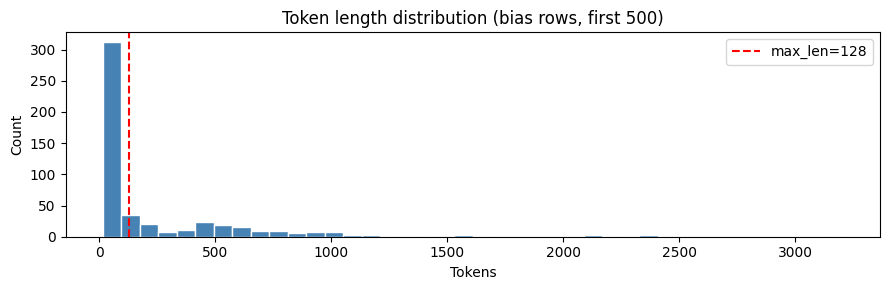

In [6]:
# ── Cell 7: Tokenizer + length check ────────────────────────────────────────
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

lengths = [len(tokenizer(r['text'], truncation=False)['input_ids']) for r in bias_rows[:500]]
print(f"Token lengths — min:{min(lengths)}  median:{int(np.median(lengths))}  p95:{int(np.percentile(lengths,95))}  max:{max(lengths)}")

plt.figure(figsize=(9, 3))
plt.hist(lengths, bins=40, color='steelblue', edgecolor='white')
plt.axvline(MAX_LEN, color='red', linestyle='--', label=f'max_len={MAX_LEN}')
plt.title('Token length distribution (bias rows, first 500)')
plt.xlabel('Tokens'); plt.ylabel('Count'); plt.legend()
plt.tight_layout(); plt.show()


In [7]:
# ── Cell 8: Dataset class ───────────────────────────────────────────────────
import torch
from torch.utils.data import Dataset

class BiasDataset(Dataset):
    def __init__(self, data, tokenizer, max_length):
        self.data       = data
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        text, label = self.data[idx]
        enc = self.tokenizer(
            text,
            truncation=True,
            max_length=self.max_length,
            padding='max_length',
            return_tensors='pt',
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'labels':         torch.tensor(label, dtype=torch.long),
        }

train_ds = BiasDataset(train_data, tokenizer, MAX_LEN)
val_ds   = BiasDataset(val_data,   tokenizer, MAX_LEN)
print(f"Train dataset: {len(train_ds):,} samples")
print(f"Val dataset:   {len(val_ds):,} samples")
print("Sample:", {k: v.shape for k, v in train_ds[0].items()})


Train dataset: 6,857 samples
Val dataset:   1,211 samples
Sample: {'input_ids': torch.Size([128]), 'attention_mask': torch.Size([128]), 'labels': torch.Size([])}


In [8]:
# ── Cell 9: Model + freeze bottom layers ────────────────────────────────────
import torch
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    BASE_MODEL,
    num_labels=2,
    id2label={0: 'NEUTRAL', 1: 'BIAS'},
    label2id={'NEUTRAL': 0, 'BIAS': 1},
    ignore_mismatched_sizes=True,
)

frozen = 0
for i, layer in enumerate(model.roberta.encoder.layer):
    if i < FREEZE_LAYERS:
        for p in layer.parameters():
            p.requires_grad = False
        frozen += 1

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Frozen layers:  {frozen}")
print(f"Total params:   {total/1e6:.1f}M")
print(f"Trainable:      {trainable/1e6:.1f}M  ({100*trainable/total:.1f}%)")


model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: Davlan/afro-xlmr-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Frozen layers:  6
Total params:   278.0M
Trainable:      235.5M  (84.7%)


In [9]:
# ── Cell 10: WeightedTrainer + metrics ──────────────────────────────────────
import torch
import numpy as np
from transformers import Trainer, TrainingArguments, EarlyStoppingCallback
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report, confusion_matrix

n_bias    = sum(1 for _, l in train_data if l == 1)
n_neutral = sum(1 for _, l in train_data if l == 0)
pos_w     = n_neutral / n_bias
print(f"n_bias={n_bias}  n_neutral={n_neutral}  pos_weight={pos_w:.2f}")

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop('labels')
        outputs = model(**inputs)
        logits  = outputs.logits
        weight  = torch.tensor([1.0, pos_w], dtype=torch.float, device=logits.device)
        loss    = torch.nn.CrossEntropyLoss(weight=weight)(logits, labels)
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'f1':        f1_score(labels, preds, average='binary'),
        'precision': precision_score(labels, preds, average='binary', zero_division=0),
        'recall':    recall_score(labels, preds, average='binary'),
    }

print("WeightedTrainer ready.")


n_bias=2581  n_neutral=4276  pos_weight=1.66
WeightedTrainer ready.


In [11]:
# ── Cell 11: Training args ───────────────────────────────────────────────────
import torch
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH,
    per_device_eval_batch_size=BATCH,
    learning_rate=LR,
    warmup_ratio=WARMUP_RATIO,
    weight_decay=WEIGHT_DECAY,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True,
    logging_steps=50,
    fp16=torch.cuda.is_available(),
    seed=SEED,
    report_to='none',
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)
print("Trainer ready.")


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Trainer ready.


In [12]:
# ── Cell 12: TRAIN ──────────────────────────────────────────────────────────
result = trainer.train()
print(f"\nDone.  Steps: {result.global_step}  Train loss: {result.training_loss:.4f}")


Epoch,Training Loss,Validation Loss,F1,Precision,Recall
1,0.250724,0.272698,0.890777,0.906173,0.875895
2,0.208438,0.279859,0.920673,0.927361,0.914081
3,0.159263,0.193811,0.923439,0.911628,0.935561
4,0.083778,0.207642,0.936121,0.911765,0.961814
5,0.105557,0.225516,0.934104,0.905830,0.964200
6,0.034113,0.229897,0.939394,0.917995,0.961814
7,0.038409,0.216762,0.948357,0.933025,0.964200
8,0.026076,0.237721,0.953846,0.946009,0.961814
9,0.021024,0.250038,0.943925,0.924485,0.964200
10,0.041439,0.255898,0.947245,0.930876,0.964200


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


Done.  Steps: 4290  Train loss: 0.1178


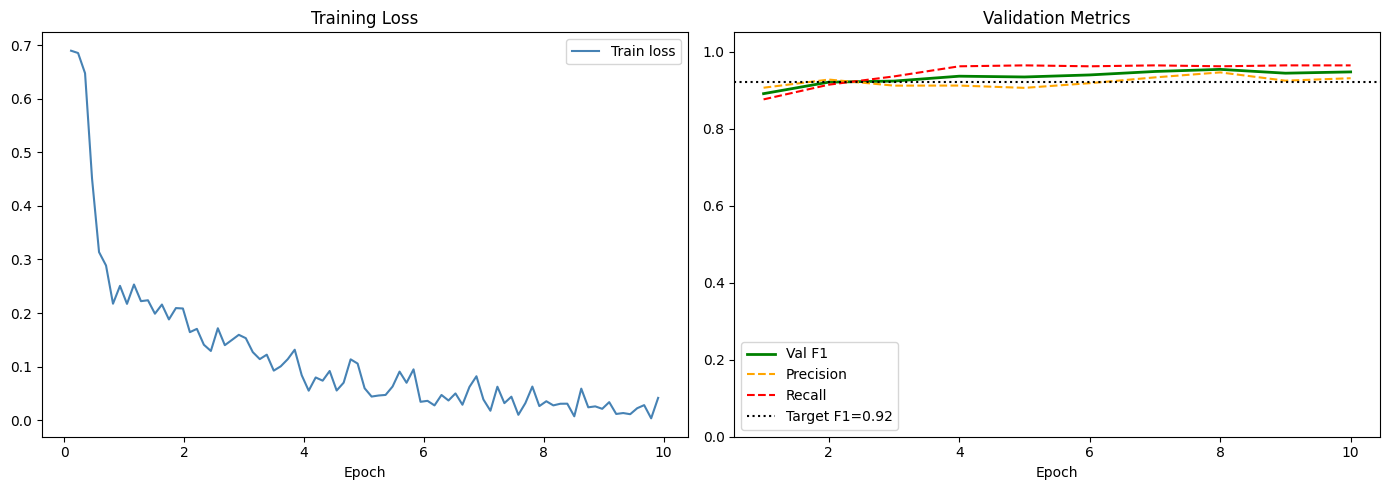

In [13]:
# ── Cell 13: Loss + F1 curves ────────────────────────────────────────────────
import matplotlib.pyplot as plt

history = trainer.state.log_history
train_loss = [(e['epoch'], e['loss'])           for e in history if 'loss' in e and 'eval_loss' not in e]
val_f1     = [(e['epoch'], e['eval_f1'])        for e in history if 'eval_f1' in e]
val_prec   = [(e['epoch'], e['eval_precision']) for e in history if 'eval_precision' in e]
val_rec    = [(e['epoch'], e['eval_recall'])    for e in history if 'eval_recall' in e]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
if train_loss:
    ax1.plot(*zip(*train_loss), color='steelblue', label='Train loss')
    ax1.set_title('Training Loss'); ax1.set_xlabel('Epoch'); ax1.legend()
if val_f1:
    ax2.plot(*zip(*val_f1),   color='green',  linewidth=2, label='Val F1')
    ax2.plot(*zip(*val_prec), color='orange', linestyle='--', label='Precision')
    ax2.plot(*zip(*val_rec),  color='red',    linestyle='--', label='Recall')
    ax2.axhline(0.92, color='black', linestyle=':', label='Target F1=0.92')
    ax2.set_ylim(0, 1.05); ax2.set_title('Validation Metrics')
    ax2.set_xlabel('Epoch'); ax2.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/training_curves.png', dpi=120)
plt.show()


              precision    recall  f1-score   support

     NEUTRAL       0.98      0.97      0.97       792
        BIAS       0.94      0.96      0.95       419

    accuracy                           0.97      1211
   macro avg       0.96      0.97      0.96      1211
weighted avg       0.97      0.97      0.97      1211



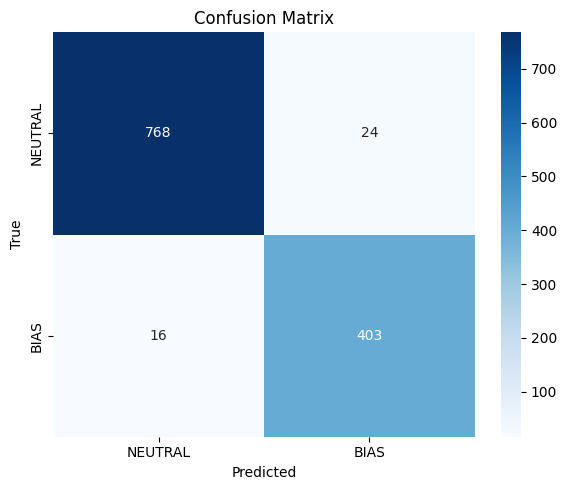


Val F1: 0.9527  (target ≥0.92)  TARGET MET


In [14]:
# ── Cell 14: Evaluation + confusion matrix ──────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score

pred_out = trainer.predict(val_ds)
preds    = np.argmax(pred_out.predictions, axis=-1)
labels   = pred_out.label_ids

print(classification_report(labels, preds, target_names=['NEUTRAL', 'BIAS']))

cm = confusion_matrix(labels, preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NEUTRAL', 'BIAS'], yticklabels=['NEUTRAL', 'BIAS'])
plt.title('Confusion Matrix'); plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/confusion_matrix.png', dpi=120)
plt.show()

final_f1 = f1_score(labels, preds, average='binary')
print(f"\nVal F1: {final_f1:.4f}  (target ≥0.92)  {'TARGET MET' if final_f1 >= 0.92 else f'gap={0.92-final_f1:.4f}'}")


In [15]:
# ── Cell 15: Error analysis ─────────────────────────────────────────────────
val_texts = [t for t, _ in val_data]

fns = [val_texts[i] for i in range(len(val_data)) if val_data[i][1]==1 and preds[i]==0]
fps = [val_texts[i] for i in range(len(val_data)) if val_data[i][1]==0 and preds[i]==1]

print(f"False Negatives (bias missed):    {len(fns)}")
print(f"False Positives (neutral flagged): {len(fps)}")

print("\n--- Top 20 False Negatives ---")
for t in fns[:20]: print(f"  {t[:90]}")

print("\n--- Top 20 False Positives ---")
for t in fps[:20]: print(f"  {t[:90]}")


False Negatives (bias missed):    16
False Positives (neutral flagged): 24

--- Top 20 False Negatives ---
  Pia, Waziri Mkuu alipiga marufuku kwa wanafunzi hao wa kike kuhudhuria kwenye ngoma hiyo y
  Mwaka 2015, madaktari wa upasuaji wa walienda kwenye Twitter kupinga hili kwa kuanzisha "#
  WAZIRI Mkuu, Kassim Majaliwa ameushukuru uongozi wa Kanisa Katoliki Jimbo la Lindi kwa kut
  NA FESTO POLEA APRILI 7 mwaka 2012 tasnia ya filamu ilipatwa na majonzi makubwa kutokana n
  WATANZANIA wametumia Swala ya Idd el – Haji kuombea nchi kuepukana na majanga kama lile wa
  WATANZANIA wametumia Swala ya Idd el – Haji kuombea nchi kuepukana na majanga kama lile la
  Msanii wa asiyechuja kwenye Bongo Fleva, Judith Wambura ‘Jaydee’ ni mfano wa wasanii wanao
  SHULE ya Msingi Diovuva iliyopo katika Kata ya Kiroka Halmashauri Wilaya ya Morogoro inaka
  NA CLARA ALPHONCE
 

 
	MSANII wa hip hop, Chemical amesema kila anapokumbuka kifo cha mam
  Na ELIYA MBONEA-MONDULI
 

 
	SIASA za Ukanda wa Afrik

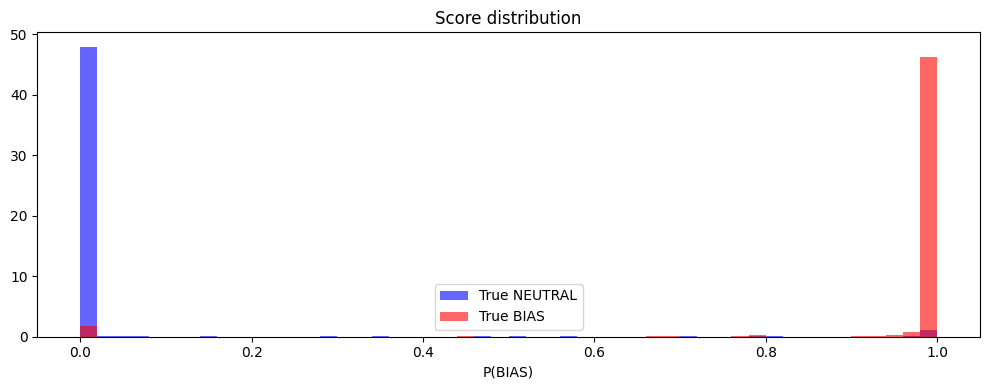

Optimal threshold: 0.56  →  F1=0.9550

>>> Set in production:  JUAKAZI_ML_THRESHOLD=0.56


In [16]:
# ── Cell 16: Optimal threshold ──────────────────────────────────────────────
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score as sk_f1

logits_t = torch.tensor(pred_out.predictions)
probs    = F.softmax(logits_t, dim=-1)[:, 1].numpy()

bias_p    = probs[labels == 1]
neutral_p = probs[labels == 0]

plt.figure(figsize=(10, 4))
plt.hist(neutral_p, bins=50, alpha=0.6, color='blue',  label='True NEUTRAL', density=True)
plt.hist(bias_p,    bins=50, alpha=0.6, color='red',   label='True BIAS',    density=True)
plt.title('Score distribution'); plt.xlabel('P(BIAS)'); plt.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/score_distribution.png', dpi=120)
plt.show()

best_t, best_f1 = 0.5, 0.0
for t in np.arange(0.20, 0.90, 0.01):
    f = sk_f1(labels, (probs >= t).astype(int), average='binary')
    if f > best_f1:
        best_f1, best_t = f, float(t)

print(f"Optimal threshold: {best_t:.2f}  →  F1={best_f1:.4f}")
print(f"\n>>> Set in production:  JUAKAZI_ML_THRESHOLD={best_t:.2f}")


In [17]:
# ── Cell 17: Save model + metadata ──────────────────────────────────────────
import json
import numpy as np
from sklearn.metrics import precision_score, recall_score

trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

opt_preds = (probs >= best_t).astype(int)
meta = {
    'model_id':      'juakazike/sw-bias-classifier-v2',
    'base_model':    BASE_MODEL,
    'ground_truth':  'ground_truth_sw_v5.csv',
    'train_size':    len(train_data),
    'val_size':      len(val_data),
    'neutral_ratio': NEUTRAL_RATIO,
    'bias_augmented': BIAS_TARGET,
    'frozen_layers': FREEZE_LAYERS,
    'epochs':        EPOCHS,
    'lr':            LR,
    'threshold':     best_t,
    'val_f1':        round(best_f1, 4),
    'val_precision': round(float(precision_score(labels, opt_preds, zero_division=0)), 4),
    'val_recall':    round(float(recall_score(labels, opt_preds)), 4),
    'id2label':      {0: 'NEUTRAL', 1: 'BIAS'},
}
with open(f'{OUTPUT_DIR}/training_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

print('Saved to:', OUTPUT_DIR)
print(json.dumps(meta, indent=2))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to: /content/output
{
  "model_id": "juakazike/sw-bias-classifier-v2",
  "base_model": "Davlan/afro-xlmr-base",
  "ground_truth": "ground_truth_sw_v5.csv",
  "train_size": 6857,
  "val_size": 1211,
  "neutral_ratio": 4,
  "bias_augmented": 3000,
  "frozen_layers": 6,
  "epochs": 10,
  "lr": 2e-05,
  "threshold": 0.5600000000000003,
  "val_f1": 0.955,
  "val_precision": 0.9482,
  "val_recall": 0.9618,
  "id2label": {
    "0": "NEUTRAL",
    "1": "BIAS"
  }
}


In [ ]:
# ── Cell 18: Download zip ───────────────────────────────────────────────────
import shutil
from google.colab import files

zip_path = '/content/sw-bias-classifier-v2'
shutil.make_archive(zip_path, 'zip', OUTPUT_DIR)
print(f'Created {zip_path}.zip')
files.download(f'{zip_path}.zip')


In [ ]:
# ── Cell 19: Upload to HuggingFace ──────────────────────────────────────────
from huggingface_hub import HfApi

HF_TOKEN = 'HF_TOKEN'   # paste your write token here
REPO_ID  = 'juakazike/sw-bias-classifier-v2'

api = HfApi()
api.create_repo(REPO_ID, token=HF_TOKEN, exist_ok=True, private=False)
api.upload_folder(folder_path=OUTPUT_DIR, repo_id=REPO_ID, token=HF_TOKEN)

print(f'Uploaded → https://huggingface.co/{REPO_ID}')
print(f'\nSet in Space env vars:')
print(f'  JUAKAZI_ML_MODEL={REPO_ID}')
print(f'  JUAKAZI_ML_THRESHOLD={best_t:.2f}')


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...kpoint-2145/rng_state.pth:  77%|#######7  | 11.3kB / 14.6kB            

  ...kpoint-1716/rng_state.pth:  77%|#######7  | 11.3kB / 14.6kB            

  ...kpoint-2574/rng_state.pth:  77%|#######7  | 11.3kB / 14.6kB            

...

  ...ckpoint-2145/optimizer.pt:   0%|          | 2.00MB / 1.88GB            

  ...nt-2145/model.safetensors:   0%|          |  556kB / 1.11GB            

  ...nt-1287/model.safetensors:   0%|          |  556kB / 1.11GB            

  ...ckpoint-2574/optimizer.pt:   1%|          | 14.0MB / 1.88GB            

Uploaded → https://huggingface.co/juakazike/sw-bias-classifier-v2

Set in Space env vars:
  JUAKAZI_ML_MODEL=juakazike/sw-bias-classifier-v2
  JUAKAZI_ML_THRESHOLD=0.56


In [20]:
# ── Cell 20: Integration test ────────────────────────────────────────────────
import torch
from transformers import pipeline as hf_pipeline

pipe = hf_pipeline(
    'text-classification',
    model=OUTPUT_DIR,
    device=0 if torch.cuda.is_available() else -1,
    truncation=True,
    max_length=MAX_LEN,
)

tests = [
    ('Daktari wa kiume alifika hospitali',                True),
    ('Mwalimu wa kike alitoa somo zuri',                  True),
    ('Wanawake hawafai kuwa viongozi wa nchi',            True),
    ('Mwanamke anapaswa kubaki nyumbani',                 True),
    ('Mhandisi wa kike alishinda tuzo ya kimataifa',      True),
    ('Mtoto wa kiume ni baraka kwa familia',              True),
    ('Rais Samia alitoa hotuba ndefu kuhusu uchumi',      False),
    ('Serikali ilifanya mikutano leo Nairobi',            False),
    ('Habari za leo kutoka Tanzania na Kenya',            False),
    ('Uchaguzi utafanyika mwezi ujao salama',             False),
]

print(f"{'Expected':8} {'Label':10} {'Score':6}  {'Pass':4}  Text")
print('-' * 80)
passed = 0
for text, expected in tests:
    r     = pipe(text)[0]
    label = r['label'].upper()
    score = r['score']
    p_bias = score if label == 'BIAS' else 1.0 - score
    ok     = predicted = p_bias >= best_t
    if ok == expected: passed += 1
    mark = 'OK' if ok == expected else 'FAIL'
    print(f"{'BIAS' if expected else 'NEU':8} {label:10} {p_bias:.3f}  {mark}   {text[:55]}")

print(f'\nResult: {passed}/{len(tests)}  {"ALL PASSED — safe to deploy" if passed==len(tests) else "review threshold"}')


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Expected Label      Score   Pass  Text
--------------------------------------------------------------------------------
BIAS     BIAS       1.000  OK   Daktari wa kiume alifika hospitali
BIAS     BIAS       1.000  OK   Mwalimu wa kike alitoa somo zuri
BIAS     BIAS       0.644  OK   Wanawake hawafai kuwa viongozi wa nchi
BIAS     BIAS       1.000  OK   Mwanamke anapaswa kubaki nyumbani
BIAS     BIAS       1.000  OK   Mhandisi wa kike alishinda tuzo ya kimataifa
BIAS     BIAS       1.000  OK   Mtoto wa kiume ni baraka kwa familia
NEU      NEUTRAL    0.000  OK   Rais Samia alitoa hotuba ndefu kuhusu uchumi
NEU      NEUTRAL    0.000  OK   Serikali ilifanya mikutano leo Nairobi
NEU      NEUTRAL    0.001  OK   Habari za leo kutoka Tanzania na Kenya
NEU      NEUTRAL    0.005  OK   Uchaguzi utafanyika mwezi ujao salama

Result: 10/10  ALL PASSED — safe to deploy
